# Visualizing results

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [25]:
score_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/scores"
score_files = {
    corpus: f"{score_dir}/scores_{corpus}.csv" for corpus in ["rocsmt", "footweets", "mmtc", "pfsmb", "rocsmt-gpt", "footweets-gpt", "mmtc-gpt", "pfsmb-gpt"]
}

In [26]:
dfs = {corpus: pd.read_csv(score_files[corpus]) for corpus in score_files}

In [27]:
from llm.prompt_templates import LLAMA_MODEL_NAME, GEMMA_MODEL_NAME, NLLB_MODEL_NAME, GUIDELINES

In [28]:
MODELS = {
    NLLB_MODEL_NAME:{
        "name": "NLLB-3B",
        "id": "0",
    },
    LLAMA_MODEL_NAME:{
        "name": "LLaMa-3.1-8B",
        "id": "1",
    },
    GEMMA_MODEL_NAME:{
        "name": "Gemma-2-9B",
        "id": "2",
    }
}

In [29]:
CORPORA = {
    "rocsmt": {
        "name": "RoCS-MT",
        "id": "0",
        "refs": "raw",
        "lang_pair": "En-Fr" 
    },
    "rocsmt-gpt": {
        "name": "RoCS-MT",
        "id": "1",
        "refs": "norm",
        "lang_pair": "En-Fr" 
    },
    "footweets": {
        "name": "FooTweets",
        "id": "2",
        "refs": "raw",
        "lang_pair": "En-De" 
    },
    "footweets-gpt": {
        "name": "FooTweets",
        "id": "3",
        "refs": "norm",
        "lang_pair": "En-De" 
    },
    "mmtc": {
        "name": "MMTC",
        "id": "4",
        "refs": "raw",
        "lang_pair": "Fr-En" 
    },
    "mmtc-gpt": {
        "name": "MMTC",
        "id": "5",
        "refs": "norm",
        "lang_pair": "Fr-En" 
    },
    "pfsmb": {
        "name": "PFSMB",
        "id": "6",
        "refs": "raw",
        "lang_pair": "Fr-En" 
    },
    "pfsmb-gpt": {
        "name": "PFSMB",
        "id": "7",
        "refs": "norm",
        "lang_pair": "Fr-En" 
    }
}

In [30]:
def get_guideline_display(guideline):
    if guideline == "default":
        return ""
    if guideline in CORPORA:
        guideline = CORPORA[guideline]["name"]
    return f" + {guideline}"

GUIDELINE_NAMES_IDS = {
    "default": 0,
    get_guideline_display("standard"): 1,
    get_guideline_display("general"): 2,
    get_guideline_display("rocsmt"): 3,
    get_guideline_display("footweets"): 4,
    get_guideline_display("mmtc"): 5,
    get_guideline_display("pfsmb"): 6,
}

In [31]:
LANG_PAIRS = {
    "RoCS-MT": "En-Fr",
    "FooTweets": "En-De",
    "MMTC": "Fr-En",
    "PFSMB": "Fr-En"
}

In [32]:
def get_guidelines(filename):
    guideline = filename.split(".")[-2]
    if guideline not in GUIDELINES:
        guideline = "default"
    return get_guideline_display(guideline)

def get_model_names(model):
    return MODELS[model.split("/")[-1]]["name"]

def get_model_id(model):
    return MODELS[model.split("/")[-1]]["id"]

def get_guideline_id(guideline):
    if not guideline:
        return GUIDELINE_NAMES_IDS["default"]
    return GUIDELINE_NAMES_IDS[guideline]

def get_corpus_id(corpus):
    return CORPORA[corpus]["id"]

def get_corpus_name(corpus):
    return CORPORA[corpus]["name"]

def get_reference_type(corpus):
    return CORPORA[corpus]["refs"]

def get_lang_pair(corpus_name):
    return LANG_PAIRS[corpus_name]

In [33]:
def normalize_error_counts(data):
    for severity in ["minor", "major", "critical"]:
        data[severity] = data[severity] / data["total"] * 100
    return data

def normalize_error_counts_sents(data):
    for severity in ["minor", "major", "critical", "correct"]:
        data[f"{severity}_sents"] = data[f"{severity}_sents"] / data["total_sents"] * 100
    return data

In [34]:
def get_lines(corpus):
    if "rocsmt" in corpus:
        return 1922
    if "footweets" in corpus:
        return 4000
    if "mmtc" in corpus:
        return 2000
    if "pfsmb" in corpus:
        return 777

In [43]:
all_data = pd.DataFrame()

for corpus in dfs:
    data = dfs[corpus].copy()
    data["guideline"] = data["file"].apply(get_guidelines)
    data["model_name"] = data["model"].apply(get_model_names) + data["guideline"] 
    data["model_id"] = data["model"].apply(get_model_id)
    data["guideline_id"] = data["guideline"].apply(get_guideline_id)
    data["corpus"] = get_corpus_name(corpus)
    data["corpus_id"] = get_corpus_id(corpus)
    data["reference_type"] = get_reference_type(corpus)
    data["total_sents"] = get_lines(corpus)
    all_data = all_data.append(data)



/home/lnishimw/scratch/tmp/ipykernel_2488279/1052779583.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_2488279/1052779583.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_2488279/1052779583.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_2488279/1052779583.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_2488279/1052779583.py:13: FutureWarning

In [44]:
all_data = all_data.sort_values(["corpus_id", "model_id", "guideline_id", "reference_type"], ascending=[True, True, True, False])
all_data.head()

,model,file,bleu,chrf2,comet,xcomet,minor,major,critical,total,...,critical_sents,correct_sents,total_sents,guideline,model_name,model_id,guideline_id,corpus,corpus_id,reference_type
0,facebook/nllb-200-3.3B,raw.en.test.out,21.332086,43.825091,73.213880,77.169062,1230,2352,105,3687,...,84,363,1922,,NLLB-3B,0,0,RoCS-MT,0,raw
1,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.default.out,20.161005,42.723988,74.026405,78.217072,1380,2499,76,3955,...,55,374,1922,,LLaMa-3.1-8B,1,0,RoCS-MT,0,raw
2,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.standard.out,20.044900,42.703130,74.139383,78.247300,1364,2498,90,3952,...,62,381,1922,+ standard,LLaMa-3.1-8B + standard,1,1,RoCS-MT,0,raw
4,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.general.out,19.975092,42.499427,74.459183,78.732861,1398,2495,80,3973,...,59,337,1922,+ general,LLaMa-3.1-8B + general,1,2,RoCS-MT,0,raw
6,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.rocsmt.out,19.736318,42.183723,74.475568,78.458084,1394,2488,75,3957,...,55,363,1922,+ RoCS-MT,LLaMa-3.1-8B + RoCS-MT,1,3,RoCS-MT,0,raw


## True references (raw) vs. GPT4-normalized references (norm)

In [35]:
def plot_scores_by_ref(all_data, metrics, sharex=True, sharey=True):
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(metrics), figsize=(4*len(metrics), 3*len(corpora)), sharex=sharex, sharey=sharey)
    for i, corpus in enumerate(corpora):
        for j, metric in enumerate(metrics):
            data = all_data[all_data["corpus"] == corpus]
            sns.barplot(x=metric, y="model_name", hue="reference_type", ax=axs[i,j], data=data) #, vmin=0, vmax=100) , cmap="YlGnBu"
            axs[i,j].set_title(f"{corpus} ({get_lang_pair(corpus)})")
            axs[i,j].set_ylabel("Model (+ Guidelines)")
    plt.tight_layout()
    plt.show()


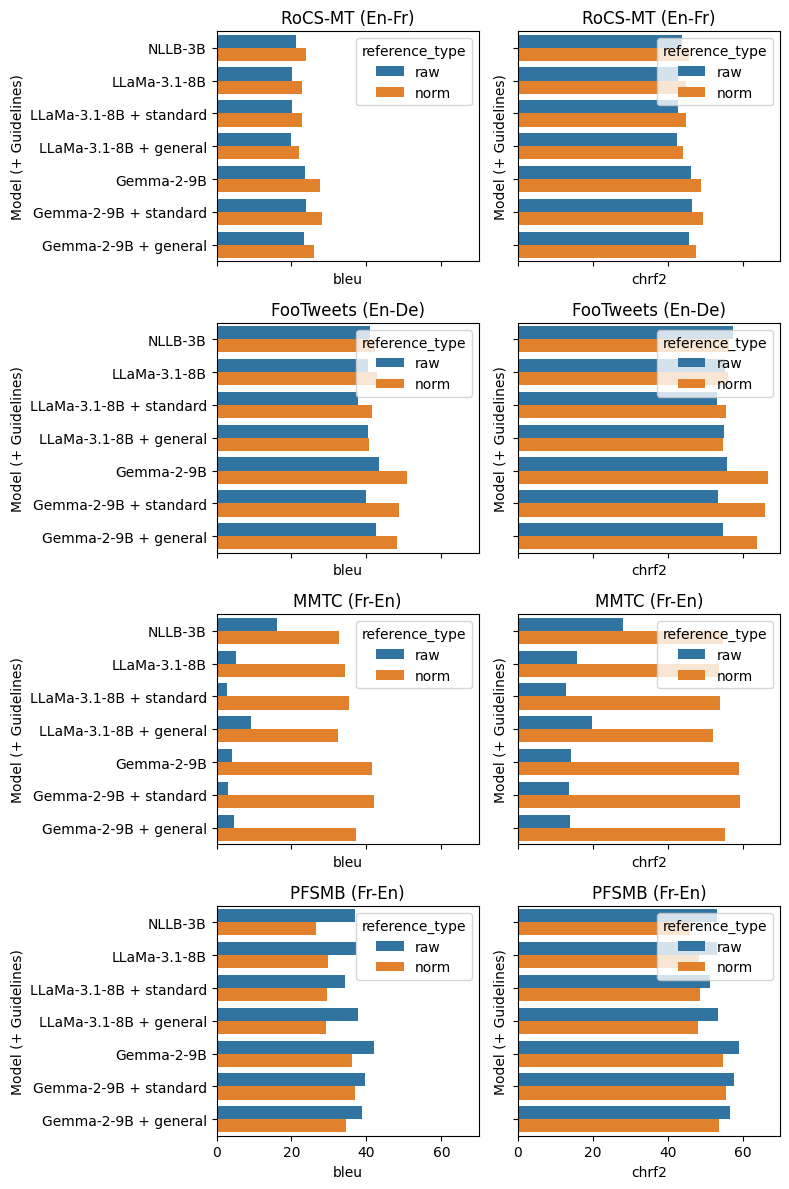

In [60]:
metrics = ["bleu", "chrf2"]
plot_scores_by_ref(all_data, metrics)

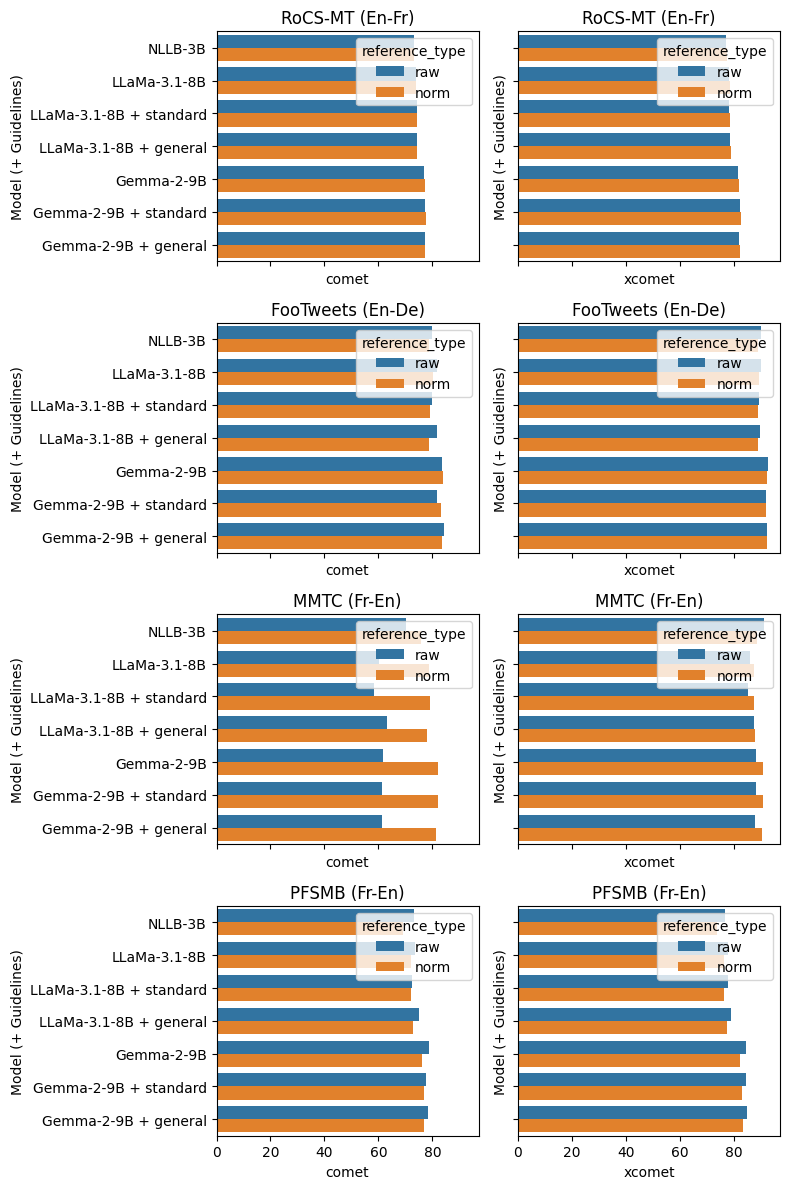

In [61]:
metrics = ["comet", "xcomet"]
plot_scores_by_ref(all_data, metrics)

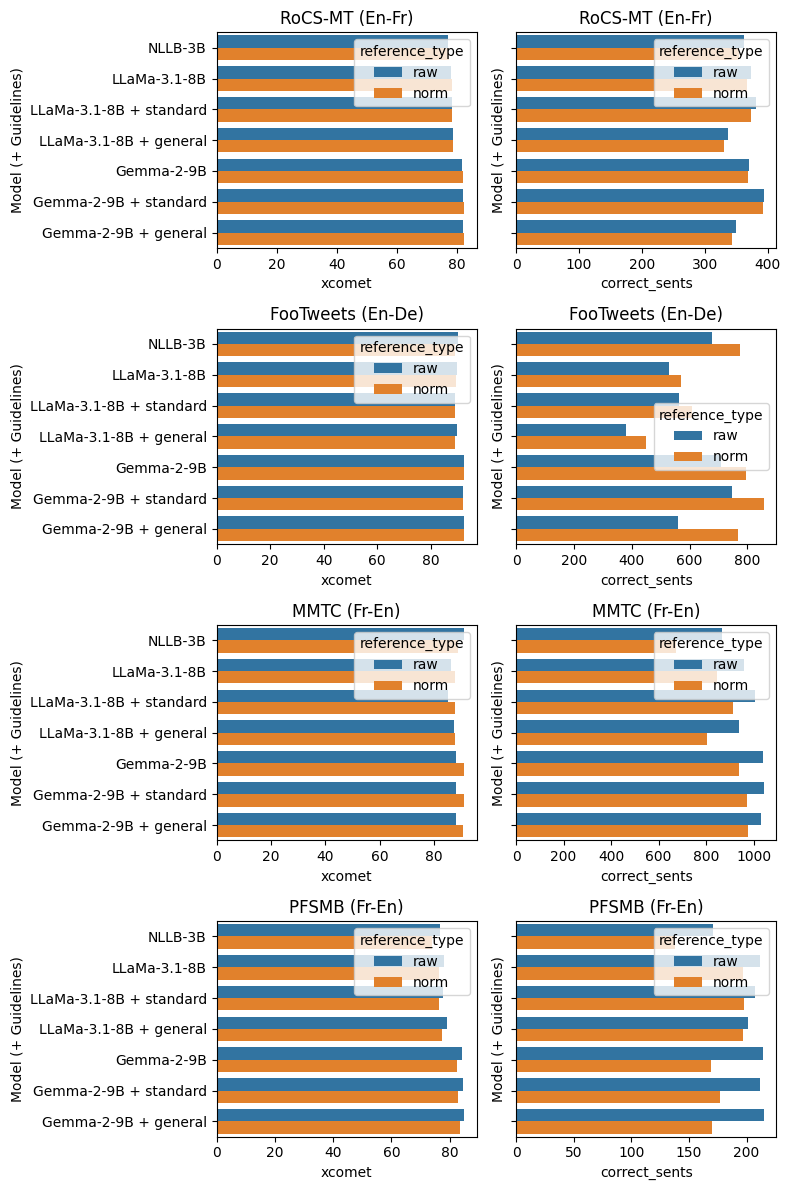

In [62]:
metrics = ["xcomet", "correct_sents"]
plot_scores_by_ref(all_data, metrics, sharex=False)

In [36]:
ERROR_SEVERITY_TYPES = ["Minor", "Major", "Critical", "None"]

def plot_error_types_by_ref(all_data):
    reference_types = all_data["reference_type"].unique()
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(reference_types), figsize=(4*len(reference_types)+1, 3*len(corpora)), sharey=True, sharex=False)
    for i, corpus in enumerate(corpora):
        for j, ref in enumerate(reference_types):
            data = all_data[(all_data["corpus"] == corpus) & (all_data["reference_type"] == ref)]
            data = data[["model_name", "minor_sents", "major_sents", "critical_sents", "correct_sents"]]
            sns.heatmap(data.set_index("model_name"), annot=True, fmt=".0f", cmap="YlGnBu", ax=axs[i,j]) #, vmin=0, vmax=100)
            axs[i,j].set_title(f"{corpus} ({ref} references)")
            axs[i,j].set_xticklabels(ERROR_SEVERITY_TYPES, rotation=0)
            axs[i,j].set_yticklabels(data["model_name"].unique(), rotation=0)
            # reduce annotations font size
            for t in axs[i,j].texts:
                t.set_fontsize(10)
    
    # Remove individual x-axis labels
    for ax in axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
    
    # Remove individual y-axis labels (except for the leftmost ones)
    for ax in axs[:,1:].flat:
        ax.set_ylabel('')
    
    fig.supylabel("Model (+ Guidelines)")
    fig.supxlabel("Error Severity")
    plt.tight_layout()
    plt.show()

plot_error_types_by_ref(all_data)

NameError: name 'all_data' is not defined

## Main plots

In [66]:
main_data = all_data[
    (all_data["reference_type"] == "raw") & 
    (~all_data["guideline"].str.contains("standard|general"))
]

In [47]:
output_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/plots"
os.makedirs(output_dir, exist_ok=True)

### xCOMET heatmaps

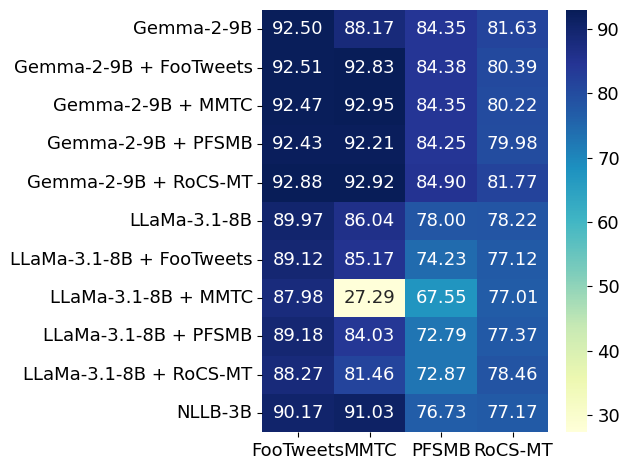

In [68]:
# plot a heatmap with the y-axis as the model and the x-axis as the corpus and the annotations as the xcomet scores
def plot_metric_heatmap(all_data, output_dir, metric="xcomet", model_names=[NLLB_MODEL_NAME, LLAMA_MODEL_NAME, GEMMA_MODEL_NAME]):
    data = all_data[all_data["model"].str.contains("|".join(model_names))]
    corpora = data["corpus"].unique()
    models = data["model_name"].unique()
    fig, ax = plt.subplots(1, 1)
    data = data.pivot(index="model_name", columns="corpus", values=metric)
    sns.heatmap(data, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_ylabel("Model (+ Guidelines)", fontsize=16)
    # ax.set_xlabel("Corpus", fontsize=16)
    # increase the font size of the annotations and the labels
    for t in ax.texts:
        t.set_fontsize(13)
    # increase the font size of the y-axis labels
    for t in ax.yaxis.get_ticklabels():
        t.set_fontsize(13)
    # increase the font size of the x-axis labels
    for t in ax.xaxis.get_ticklabels():
        t.set_fontsize(13)
    # increase the font size of the colorbar labels
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{metric}_heatmap_{'_'.join(model_names)}.pdf", format="pdf")


plot_metric_heatmap(main_data, output_dir, "xcomet")


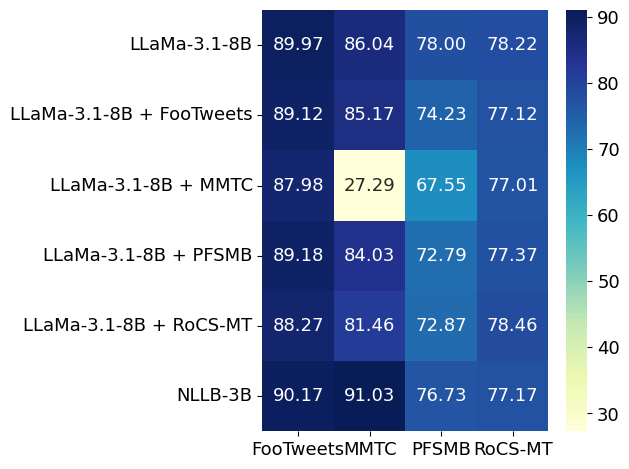

In [69]:
plot_metric_heatmap(main_data, output_dir, "xcomet", [NLLB_MODEL_NAME, LLAMA_MODEL_NAME])

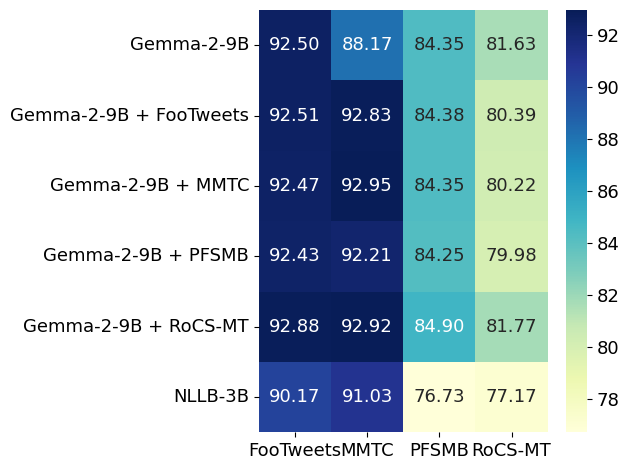

In [70]:
plot_metric_heatmap(main_data, output_dir, "xcomet", [NLLB_MODEL_NAME, GEMMA_MODEL_NAME])

### Error types heatmaps

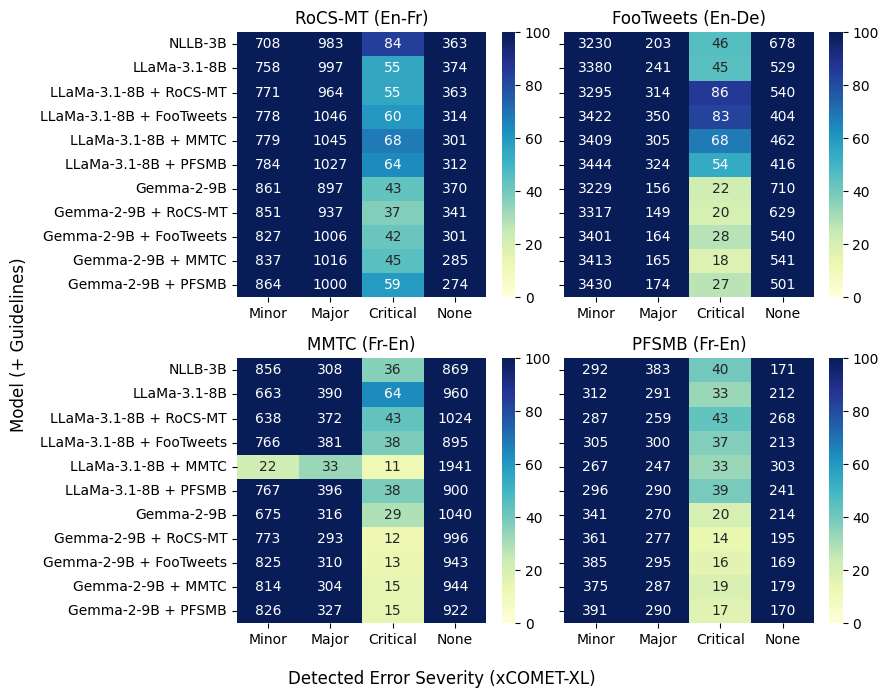

In [50]:
def plot_error_types_sents(all_data, output_dir):
    corpora = all_data["corpus"].unique()
    n_cols = 2
    n_rows = math.ceil(len(corpora) / n_cols)
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols+1, 3*n_rows+1), sharey=True, sharex=False)
    for k, corpus in enumerate(corpora):
        i, j = divmod(k, n_cols)
        data = all_data[all_data["corpus"] == corpus]
        data = data[["model_name", "minor_sents", "major_sents", "critical_sents", "correct_sents"]]
        sns.heatmap(data.set_index("model_name"), annot=True, fmt=".0f", cmap="YlGnBu", ax=axs[i,j], vmin=0, vmax=100)
        axs[i,j].set_title(f"{corpus} ({get_lang_pair(corpus)})")
        axs[i,j].set_xticklabels(ERROR_SEVERITY_TYPES, rotation=0)
        # reduce annotations font size
        for t in axs[i,j].texts:
            t.set_fontsize(10)
    
    # Remove individual x-axis labels
    for ax in axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
    
    # Remove individual y-axis labels (except for the leftmost ones)
    for ax in axs[:,1:].flat:
        ax.set_ylabel('')
    
    fig.supylabel("Model (+ Guidelines)")
    fig.supxlabel("Detected Error Severity (xCOMET-XL)")
    plt.tight_layout()
    # save plot to output dir
    plt.savefig(f"{output_dir}/error_types_sents_heatmap.pdf", format="pdf")

# raw_data_norm_sent_counts = normalize_error_counts_sents(raw_data)
# plot_error_types(raw_data_norm_sent_counts)
plot_error_types_sents(main_data, output_dir)

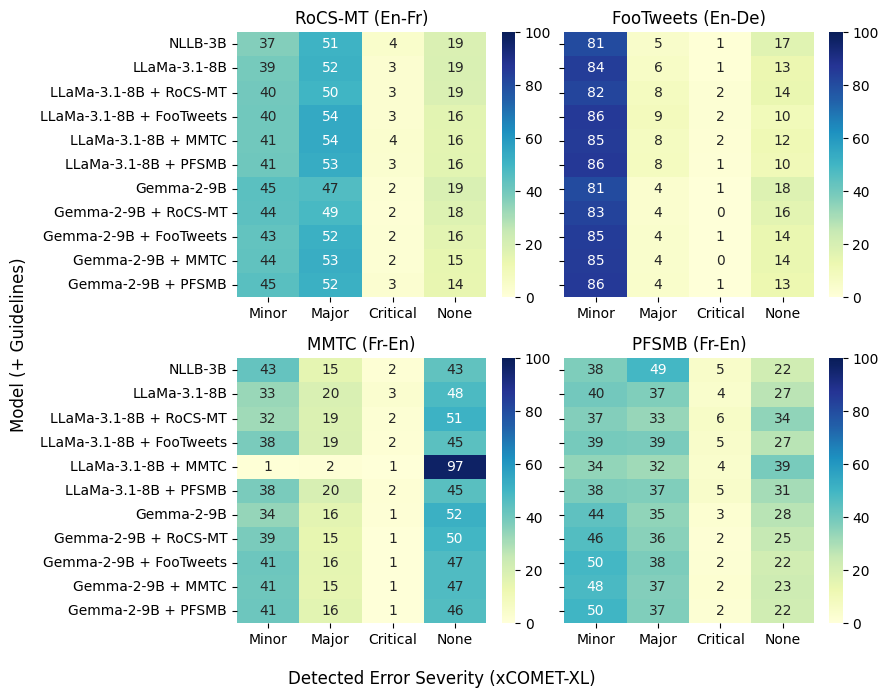

In [51]:
main_data_norm_sent_counts = normalize_error_counts_sents(main_data.copy())
# plot_error_types(raw_data_norm_sent_counts)
plot_error_types_sents(main_data_norm_sent_counts, output_dir)

# Analyzing error types

In [38]:
import json

In [39]:
def get_errors(errors, severity):
    sentence_ids = []
    for i, sentence in enumerate(errors):
        for span in sentence["spans"]:
            if span["severity"] == severity:
                sentence_ids.append(i)
                break
    return set(sentence_ids)

def get_correct(errors):
    sentence_ids = []
    for i, sentence in enumerate(errors):
        if len(sentence["spans"]) == 0:
            sentence_ids.append(i)
    return set(sentence_ids)

In [4]:
src_file = "/home/lnishimw/scratch/datasets/mmtc/test.fr-en.fr"
ref_file = "/home/lnishimw/scratch/datasets/mmtc/test.fr-en.en"
ref_file_norm = "/home/lnishimw/scratch/datasets/mmtc/gpt.test.fr-en.en"

def read_file(file):
    with open(file, "r") as f:
        #get lines without newline character
        return [line.strip() for line in f.readlines()]

src = read_file(src_file)
ref = read_file(ref_file)
ref_norm = read_file(ref_file_norm)


In [12]:
model = "google/gemma-2-9b-it"
guideline = "default."
sys_file = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc/test.fr-en.fr.{guideline}out"
error_file = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc/test.fr-en.fr.{guideline}out.errors.json"
error_file_norm = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc-gpt/test.fr-en.fr.{guideline}out.errors.json"

with open(error_file, "r") as f:
    errors = json.load(f)

with open(error_file_norm, "r") as f:
    errors_norm = json.load(f)

sys = read_file(sys_file)

In [13]:
critical_errors = get_errors(errors, "critical")
critical_errors_norm = get_errors(errors_norm, "critical")

major_errors = get_errors(errors, "major")
major_errors_norm = get_errors(errors_norm, "major")

minor_errors = get_errors(errors, "minor")
minor_errors_norm = get_errors(errors_norm, "minor")

In [14]:
all_errors = critical_errors.union(major_errors).union(minor_errors)
all_errors_norm = critical_errors_norm.union(major_errors_norm).union(minor_errors_norm)

In [15]:
no_errors = get_correct(errors)
no_errors_norm = get_correct(errors_norm)

In [16]:
print("raw", "gpt")
print(len(critical_errors), len(critical_errors_norm))
print(len(major_errors), len(major_errors_norm))
print(len(minor_errors), len(minor_errors_norm))
print(len(all_errors), len(all_errors_norm))
print(len(no_errors), len(no_errors_norm))


raw gpt
29 23
316 365
675 749
960 1063
1040 937


In [17]:
# get intersection of critical errors
intersection = critical_errors.intersection(all_errors)
print(len(intersection))

29


In [18]:
for i in critical_errors:
    print("Line", (i+1))
    print("SRC:", src[i])
    print("SYS:", sys[i])
    print("REF (raw):", ref[i])
    print("ERRORS (raw):", errors[i])
    print("REF (gpt):", ref_norm[i])
    print("ERRORS (gpt):", errors_norm[i])
    print()

Line 387
SRC: @Ludo_Perverie Déjà fait l'an dernier
SYS: Already did it last year.
REF (raw): @Ludo_Perverie Already done last year
ERRORS (raw): {'score': 0.6809611320495605, 'spans': [{'text': 'Already did', 'confidence': 0.38789039850234985, 'severity': 'critical', 'start': 0, 'end': 11}]}
REF (gpt): Already done last year.
ERRORS (gpt): {'score': 0.9078869223594666, 'spans': [{'text': 'did', 'confidence': 0.3566102385520935, 'severity': 'minor', 'start': 7, 'end': 11}]}

Line 1667
SRC: RT @abracadaspliff: qui s'absente, ce fait oublier et aussitôt remplacé
SYS: Out of sight, out of mind and quickly replaced.
REF (raw): RT @abracadaspliff: he who is away, is forgotten and immediately replaced
ERRORS (raw): {'score': 0.4102344214916229, 'spans': [{'text': 'Out of sight, out of mind', 'confidence': 0.6553688049316406, 'severity': 'critical', 'start': 0, 'end': 25}]}
REF (gpt): He who is away is forgotten and immediately replaced.
ERRORS (gpt): {'score': 0.6081463098526001, 'spans': [{

# Qualitative Analysis

## Selected examples

In [1]:
import json, yaml, os

In [2]:
corpus = "rocsmt"
rocsmt_line_numbers = [9,11,18,36,43,51,56,80,91,97,102,120,153,160,164,180,220,248,264,283,319,347,369,416,478,536,574,593,624,633,655,666,750,780,805,807,817,838,904,906,907,922,930,951,976,980,996,1015,1034,1047,1134,1153,1193,1205,1207,1230,1275,1311,1436,1462,1468,1482,1537,1548,1593,1596,1643,1648,1665,1739,1768,1780,1803,1922]
rocsmt_lines_ids = [k - 1 for k in rocsmt_line_numbers]

In [3]:
corpus = "footweets"
footweets_line_numbers = [2,3,7,18,21,22,24,26,30,35,177,195,337,374,414,422,525,536,573,610,637,707,718,914,1011,1093,1097,1350,1566,1567,1568,1569,1571,1612,1817,1992,2148,2420,2444,2525,2526,2544,2548,2590,2669,2670,2692,2813,2853,2885,2953,3354,3490,3566,3799,3910,3933,3986]
footweets_lines_ids = [k - 1 for k in footweets_line_numbers]

In [4]:
corpus = "mmtc"
mmtc_line_numbers = [1, 6, 8, 82, 96, 131, 188, 289, 301, 332, 441, 457, 610, 621, 667, 792, 801, 891, 976, 1008, 1035, 1179, 1262, 1465, 1522, 1627, 1643, 1667, 1712, 1746, 1763, 1774, 1782, 1862, 1898, 1935, 1963, 1999] 
mmtc_lines_ids = [k - 1 for k in mmtc_line_numbers]

In [5]:
corpus = "pfsmb"
pfsmb_line_numbers = [3,27,32,34,35,45,46,63,78,105,117,119,122,129,152,166,173,186,204,298,303,306,421,427,438,467,471,503,523,640,656,657,669,687,688,731,744,770]
pfsmb_lines_ids = [k - 1 for k in pfsmb_line_numbers]

In [6]:
corpora_config_file = "/home/lnishimw/evaluation-challenges/src/llm/config/corpora.yaml"
with open(corpora_config_file, "r") as f:
    corpora_config = yaml.safe_load(f)

In [7]:
corpora_config

{'rocsmt': {'src_file_path': '$DATASETS/rocsmt/test/raw.en.test',
  'ref_file_path': '$DATASETS/rocsmt/test/ref.fr.test'},
 'footweets': {'src_file_path': '$DATASETS/footweets/detok.twitter.sent.en.txt',
  'ref_file_path': '$DATASETS/footweets/detok.twitter.sent.de.txt'},
 'mmtc': {'src_file_path': '$DATASETS/mmtc/test.fr-en.fr',
  'ref_file_path': '$DATASETS/mmtc/test.fr-en.en'},
 'pfsmb': {'src_file_path': '$DATASETS/pfsmb/test.fr',
  'ref_file_path': '$DATASETS/pfsmb/test.en'},
 'rocsmt-gpt': {'src_file_path': '$DATASETS/rocsmt/test/raw.en.test',
  'ref_file_path': '$DATASETS/rocsmt/test/gpt.ref.fr.test'},
 'footweets-gpt': {'src_file_path': '$DATASETS/footweets/detok.twitter.sent.en.txt',
  'ref_file_path': '$DATASETS/footweets/gpt.detok.twitter.sent.de.txt'},
 'mmtc-gpt': {'src_file_path': '$DATASETS/mmtc/test.fr-en.fr',
  'ref_file_path': '$DATASETS/mmtc/gpt.test.fr-en.en'},
 'pfsmb-gpt': {'src_file_path': '$DATASETS/pfsmb/test.fr',
  'ref_file_path': '$DATASETS/pfsmb/gpt.test.en

In [8]:
analysis_lines = {
    "rocsmt": rocsmt_lines_ids,
    "footweets": footweets_lines_ids,
    "mmtc": mmtc_lines_ids,
    "pfsmb": pfsmb_lines_ids,
}

In [9]:
def read_file(file):
    with open(file, "r") as f:
        #get lines without newline character
        return [line.strip() for line in f.readlines()]
    
def read_json(file):
    with open(file, "r") as f:
        return json.load(f)


In [10]:
NLLB = "facebook/nllb-200-3.3B"


In [17]:
def get_outputs(line_ids, src, ref, sys, errors):
    output = ""
    for i in line_ids:
        output += f"Line {i+1}\n"
        output += f"SRC: {src[i]}\n"
        output += f"REF: {ref[i]}\n"
        for guideline in sys:
            output += "------------------------------\n"
            output += f"SYS ({guideline}): {sys[guideline][i]}\n"
            output += f"ERRORS ({guideline}): {errors[guideline][i]}\n"
        output += "\n"
    return output

In [21]:
corpus = "pfsmb"
model = "google/gemma-2-9b-it" # "meta-llama/Llama-3.1-8B-Instruct" #
experiment_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/"
guidelines = ["baseline", "default", "rocsmt", "footweets", "mmtc", "pfsmb"]

src_file = os.path.expandvars(corpora_config[corpus]["src_file_path"])
ref_file = os.path.expandvars(corpora_config[corpus]["ref_file_path"])
src_file_name = os.path.basename(src_file)
src = read_file(src_file)
ref = read_file(ref_file)

sys = {}
errors = {}
for guideline in guidelines:
    sys_model = NLLB if (guideline == "baseline") else model
    guideline_ext = "out" if (guideline == "baseline") else  f"{guideline}.out"
    sys_file = f"{experiment_dir}/outputs/{sys_model}/{corpus}/{src_file_name}.{guideline_ext}"
    error_file = f"{experiment_dir}/outputs/{sys_model}/{corpus}/{src_file_name}.{guideline_ext}.errors.json"
    errors[guideline] = read_json(error_file)
    sys[guideline] = read_file(sys_file)




In [ ]:
output_dir = f"{experiment_dir}/analysis/{model}/{corpus}"
os.makedirs(output_dir, exist_ok=True)

In [22]:
print(get_outputs(analysis_lines[corpus], src, ref, sys, errors))

Line 3
SRC: Brrrrrrrrrrr il fait froid .....
REF: Brrrrrrrrrrr it's cold .....
------------------------------
SYS (baseline): Brrrrrrrrr it is cold.....
ERRORS (baseline): {'score': 0.9907239675521851, 'spans': []}
------------------------------
SYS (default): It's freezing cold....
ERRORS (default): {'score': 0.981534481048584, 'spans': []}
------------------------------
SYS (rocsmt): Brrrrrrrr it's cold...
ERRORS (rocsmt): {'score': 0.9778526425361633, 'spans': [{'text': 'rrr', 'confidence': 0.4182392656803131, 'severity': 'minor', 'start': 6, 'end': 9}]}
------------------------------
SYS (footweets): Brrrrrrrrrrr it's cold.....
ERRORS (footweets): {'score': 0.9775128364562988, 'spans': [{'text': 'rrr', 'confidence': 0.4176812171936035, 'severity': 'minor', 'start': 9, 'end': 12}]}
------------------------------
SYS (mmtc): Brrrrrrrrrrr it's cold.....
ERRORS (mmtc): {'score': 0.9775128364562988, 'spans': [{'text': 'rrr', 'confidence': 0.4176812171936035, 'severity': 'minor', 'start'

## Critical errors

In [40]:
critical_errors = {}
for guideline in errors:
    critical_errors[guideline] = get_errors(errors[guideline], "critical")

In [41]:
critical_errors["all"] = set()
for guideline in critical_errors:
    print(guideline, len(critical_errors[guideline]))
    critical_errors["all"] = critical_errors["all"].union(critical_errors[guideline])


baseline 40
default 20
rocsmt 14
footweets 16
mmtc 19
pfsmb 17
all 68


In [42]:
print(get_outputs(critical_errors["all"], src, ref, sys, errors))

Line 259
SRC: A koi tu pensé a ce moment??
REF: Wat were u thinkin about in this moment??
------------------------------
SYS (baseline): What did you think of at that moment?
ERRORS (baseline): {'score': 0.9872174263000488, 'spans': []}
------------------------------
SYS (default): Did you ever think about this at this moment??
ERRORS (default): {'score': 0.9502670764923096, 'spans': [{'text': 'ever think', 'confidence': 0.40138834714889526, 'severity': 'minor', 'start': 7, 'end': 18}]}
------------------------------
SYS (rocsmt): Did you ever think about this moment??
ERRORS (rocsmt): {'score': 0.790791392326355, 'spans': [{'text': 'Did', 'confidence': 0.4059988260269165, 'severity': 'major', 'start': 0, 'end': 3}, {'text': 'ever think about this moment', 'confidence': 0.4344784915447235, 'severity': 'major', 'start': 7, 'end': 36}]}
------------------------------
SYS (footweets): Did you ever think about this moment??
ERRORS (footweets): {'score': 0.790791392326355, 'spans': [{'text'